<a href="https://colab.research.google.com/github/DuongBMTTNC/Cloud_DA/blob/main/OULAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")

100%|██████████| 42.2M/42.2M [00:00<00:00, 212MB/s]

Extracting files...


In [ ]:
import pandas as pd
import os
os.listdir(path)

['courses.csv',
 'vle.csv',
 'studentAssessment.csv',
 'studentInfo.csv',
 'studentVle.csv',
 'studentRegistration.csv',
 'assessments.csv']

In [ ]:
student_info = pd.read_csv(path + '/studentInfo.csv')
student_vle = pd.read_csv(path + '/studentVle.csv')
student_assessment = pd.read_csv(path + '/studentAssessment.csv')
assessments = pd.read_csv(path + '/assessments.csv')

In [ ]:
active_days = student_vle.groupby('id_student')['date'].nunique().reset_index()
active_days.columns = ['id_student', 'active_days']

In [ ]:
total_clicks = student_vle.groupby('id_student')['sum_click'].sum().reset_index()
total_clicks.columns = ['id_student', 'total_clicks']

In [ ]:
avg_score = student_assessment.groupby('id_student')['score'].mean().reset_index()
avg_score.columns = ['id_student', 'avg_score']

In [ ]:
df = student_info[['id_student', 'final_result']]

df = df.merge(active_days, on='id_student', how='left')
df = df.merge(total_clicks, on='id_student', how='left')
df = df.merge(avg_score, on='id_student', how='left')

In [ ]:
df.fillna(0, inplace=True)

In [ ]:
def classify_activity(x):
    if x < 50:
        return 'Low'
    elif x < 150:
        return 'Medium'
    else:
        return 'High'

df['activity_level'] = df['active_days'].apply(classify_activity)

In [ ]:
df[['active_days', 'total_clicks', 'avg_score']].corr()

,active_days,total_clicks,avg_score
active_days,1.000000,0.831373,0.552719
total_clicks,0.831373,1.000000,0.412395
avg_score,0.552719,0.412395,1.000000


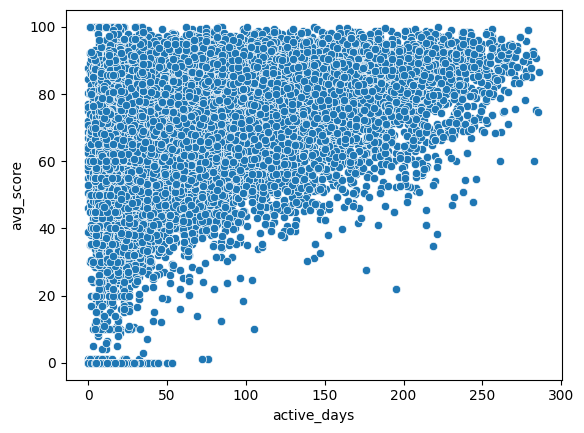

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='active_days', y='avg_score')
plt.show()

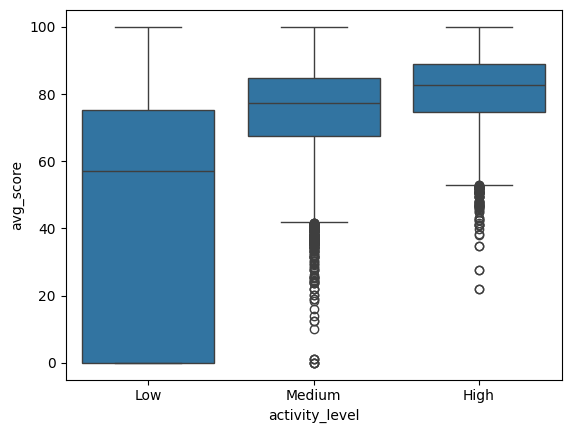

In [ ]:
sns.boxplot(data=df, x='activity_level', y='avg_score')
plt.show()

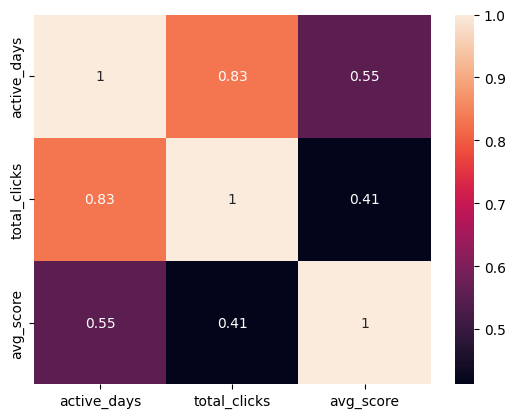

In [ ]:
sns.heatmap(df[['active_days','total_clicks','avg_score']].corr(), annot=True)
plt.show()

In [ ]:
low = df[df['activity_level'] == 'Low']
medium = df[df['activity_level'] == 'Medium']
high = df[df['activity_level'] == 'High']

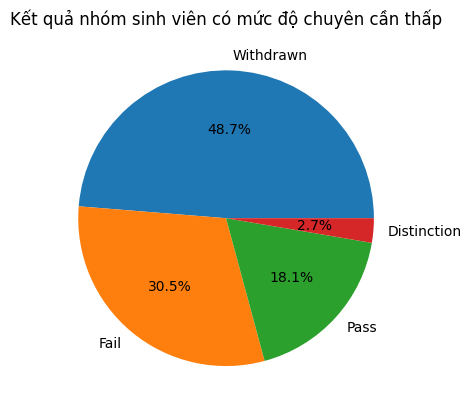

In [ ]:
low['final_result'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Kết quả nhóm sinh viên có mức độ chuyên cần thấp")
plt.ylabel('')
plt.show()

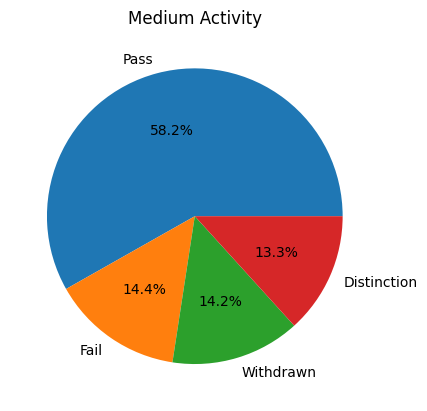

In [ ]:
medium['final_result'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Kết quả nhóm sinh viên có mức độ chuyên cần trung bình")
plt.ylabel('')
plt.show()

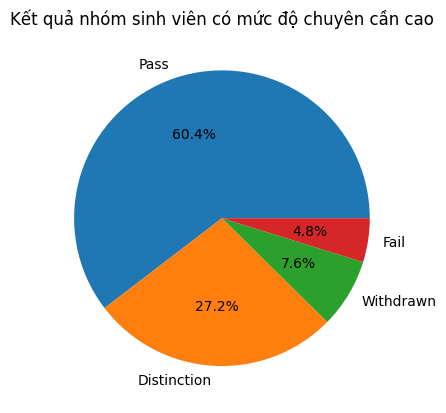

In [ ]:
high['final_result'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Kết quả nhóm sinh viên có mức độ chuyên cần cao")
plt.ylabel('')
plt.show()

In [ ]:
df['engagement_score'] = df['active_days'] + df['total_clicks'] / 100

In [ ]:
def classify_engagement(x):
    if x < 100:
        return 'Low'
    elif x < 300:
        return 'Medium'
    else:
        return 'High'

df['engagement_level'] = df['engagement_score'].apply(classify_engagement)

<Axes: xlabel='engagement_score', ylabel='avg_score'>

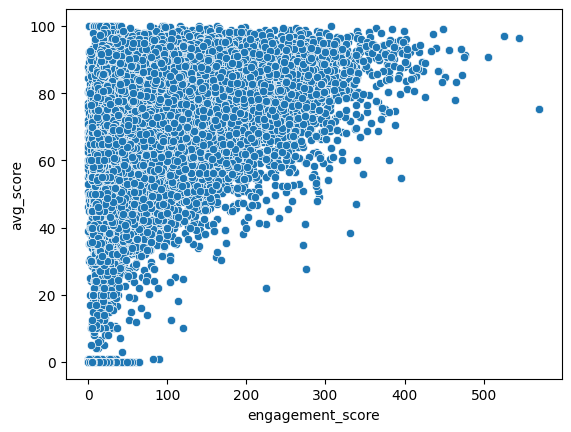

In [ ]:
sns.scatterplot(data=df, x='engagement_score', y='avg_score')

<Axes: xlabel='engagement_level', ylabel='avg_score'>

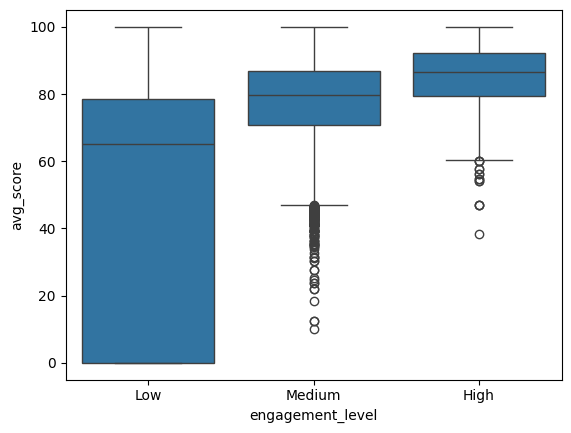

In [ ]:
sns.boxplot(data=df, x='engagement_level', y='avg_score')

<Axes: ylabel='count'>

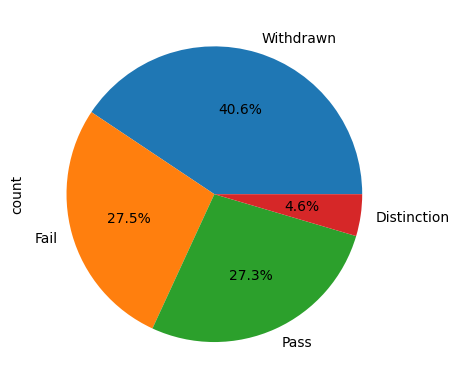

In [ ]:
df[df['engagement_level']=='Low']['final_result'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: ylabel='count'>

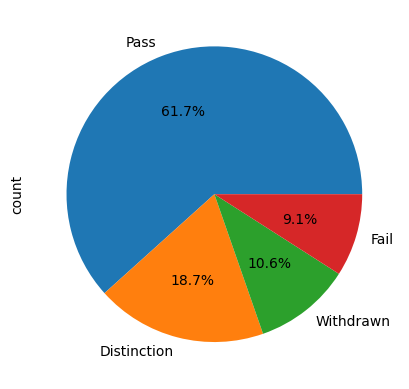

In [ ]:
df[df['engagement_level']=='Medium']['final_result'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: ylabel='count'>

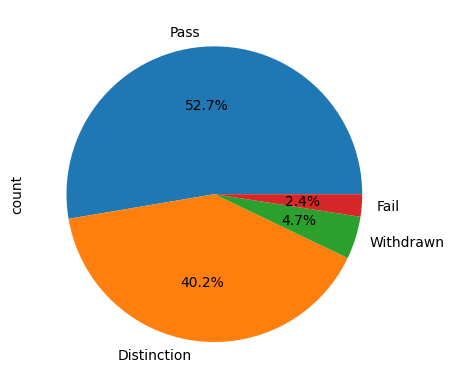

In [ ]:
df[df['engagement_level']=='High']['final_result'].value_counts().plot.pie(autopct='%1.1f%%')